In [1]:
from glob import glob 

for g in glob('./data/*.pdf'):
    print(g)

./data\2040_seoul_plan.pdf
./data\OneNYC_2050_Strategic_Plan.pdf
./data\프롬프트 명령어_한글.pdf


In [2]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

def read_pdf_and_split_text(pdf_path, chunk_size=1000, chunk_overlap=100):
    """
    주어진 PDF 파일을 읽고 텍스트를 분할합니다.
    매개변수:
        pdf_path (str): PDF 파일의 경로.
        chunk_size (int, 선택적): 각 텍스트 청크의 크기. 기본값은 1000입니다.
        chunk_overlap (int, 선택적): 청크 간의 중첩 크기. 기본값은 100입니다.
    반환값:
        list: 분할된 텍스트 청크의 리스트.
    """
    print(f"PDF: {pdf_path} -----------------------------")

    pdf_loader = PyPDFLoader(pdf_path)
    data_from_pdf = pdf_loader.load()

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size, chunk_overlap=chunk_overlap
    )

    splits = text_splitter.split_documents(data_from_pdf)
    
    print(f"Number of splits: {len(splits)}\n")
    return splits


In [3]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_chroma import Chroma
from dotenv import load_dotenv
import os

load_dotenv()

##### Vectorstore 설정 #####
embedding = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001",
    google_api_key=os.getenv("GEMINI_API_FREE_KEY") or os.getenv("GEMINI_API_KEY")
)

persist_directory='./chroma_store'

if os.path.exists(persist_directory):
    print("Loading existing Chroma store")
    vectorstore = Chroma(
        persist_directory=persist_directory,
        embedding_function=embedding
    )
else:
    print("Creating new Chroma store")

    vectorstore = None
    for g in glob('./data/*.pdf'):
        chunks = read_pdf_and_split_text(g)
        # 100개씩 나눠서 저장
        for i in range(0, len(chunks), 100):
            if vectorstore is None:
                vectorstore = Chroma.from_documents(
                    documents=chunks[i:i+100],
                    embedding=embedding,
                    persist_directory=persist_directory
                )
            else:
                vectorstore.add_documents(
                    documents=chunks[i:i+100]
                )

Creating new Chroma store
PDF: ./data\2040_seoul_plan.pdf -----------------------------
Number of splits: 308

PDF: ./data\OneNYC_2050_Strategic_Plan.pdf -----------------------------
Number of splits: 1023

PDF: ./data\프롬프트 명령어_한글.pdf -----------------------------
Number of splits: 33



In [4]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

chunks = retriever.invoke("서울 온실가스 저감 계획")

for chunk in chunks:
    print(chunk.metadata)
    print(chunk.page_content)


{'moddate': '2024-12-12T18:16:11+09:00', 'pdfversion': '1.4', 'total_pages': 205, 'creationdate': '2024-12-12T18:16:11+09:00', 'creator': 'Hwp 2020 11.0.0.5178', 'page': 63, 'producer': 'Hancom PDF 1.3.0.542', 'page_label': '64', 'author': 'SI', 'source': './data\\2040_seoul_plan.pdf'}
56제2장 미래상과 목표
6. 미래위기를 준비하는, ‘탄소중립 안전도시 구축’1) 배경전(全) 지구적인 기후변화에 대응하기 위한 대도시 차원의 대응 필요Ÿ서울시 2017년 온실가스 배출량은 46,685천 톤CO2eq로 2005년 배출량에 비해 5.6%(276만 톤CO2eq) 감소하였으며, 서울의 1인당 온실가스 배출량은 4.7CO2eq로 국가의 13.8톤CO2eq에 비해 낮은 수준이다. 또한 2014년 기준 서울의 1인당 온실가스 배출량은 4.5CO2eq로 세계 주요 도시에 비해 낮은 수준을 보인다.7)
[그림 2-26] 세계 주요 도시 1인당 온실가스 배출량   자료: World Bank, 2014Ÿ그럼에도 불구하고, 기후변화 문제는 21세기에 전 지구적으로 가장 위중한 영향을 미칠 것으로 예상되는바, 탄소중립과 기후위기 대응은 국제·국가·도시의 핵심 정책으로 다루어져야 한다.Ÿ파리협정(2015) 이후, 우리나라를 비롯한 미국, 유럽연합 등 세계 136개국이 탄소중립을 선언하였으며, 서울시를 비롯한 뉴욕, 런던 등과 같은 많은 글로벌 도시에서 탄소중립을 시정의 핵심과제로 추진 중이다.Ÿ우리나라는 2020년 ‘한국판 그린뉴딜’을 발표하며 공식적으로 2050 탄소중립을 선언하였으며 서울시 역시 2020년 ‘그린뉴딜 추진을 통한 2050 온실가스 감축 전략’을 발표하고 탄소중립 선언에 따른 부문별 사업을 적극 추진하고 있다.-서울시는 2050년 탄소중립을 목표

In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os

load_dotenv()

# 모델 초기화
model = ChatGoogleGenerativeAI(
    model=os.getenv("GEMINI_MODEL", "gemini-2.0-flash"),
    google_api_key=os.getenv("GEMINI_API_FREE_KEY") or os.getenv("GEMINI_API_KEY")
)

model.invoke('안녕하세요!')

AIMessage(content=[{'type': 'text', 'text': '안녕하세요! 반가워요. 무엇을 도와드릴까요? 궁금한 점이 있거나 도움이 필요하시면 언제든 말씀해 주세요.', 'extras': {'signature': 'EpkHCpYHAb4+9vvNFCsyyolUKT0kPP0KzhV7z5lDfD9jBHSxpTLrUMRReUB9Sgopkb2r4mgxfKMN4dv/N2wA1lFth7oeglQnjQ2WtVFPlORUctj754JtJj9QsSGq04K+mEa+qdpcZhcK4Tb9b6afEO8T1gtVOv1GvGF4KNnsyhfVrrJqTBjsGEZ7mu5eGoNMF7hlgij1dg9grGXXC4okdvclipnXkiHr3BivZ+FcRrkRMKqrLHgo3qwFF7WnjOm1D7MPKg1zlgHx802hr8+M9BQkcbxZMDF7hV86dOPx8xM3MrYqALRwprPy8pD4mrpNPYtNRt+TN1UflvLd2F8QCZsKVXrmEMHoROw+74SGN8rvWwuH2dVz9UaUGoHpi6CPtkw/S1nSc+bCUR31MArwkdGiNLukHusZZqhVBF1vgzBCLu901SBFnl/7QC6eVO7Wb8f3nXMhzTtsxGnAgJQRBw5HsJyVX4HO7dKI3F7adKDwLXx2p9njJJQJyQwJ2xFHY1+T33/lfhW5LiLyf+YbKN6YO7vfkhMktq3Jj9NWt2jqU9XKmVMLTtoH1kITZwSNoIPVIB6M0bjZ2WItJBlvAwTc5g90pwv+ywB+ofh3Ia6/PykrI88eAYWhoImGBhhE+9Zp/od4cwFRl8QcqUCPL4QwbrAHsgXhtuR2B+K7HDnRG0iLJq09HdcUdEUwa7/6faCyRIABRSiccJGw5HAAEiu/aQDFHe144xSicQ1L+7Fg8GKHJUZ1S3R1uSrVt6s4Bs/fAkji31+0vNee2nT7PfsOY9E+x3q8+L2ta9gv5zqY9k/1eXpjM7VwMLQoSYTsF6xKQDvA8WlMIQVB8raQEwRB6akkcUIrL6XfM

In [6]:
# Router 설정
from langchain_core.prompts import ChatPromptTemplate
from typing import Literal # 문자열 리터럴 타입을 지원하는 typing 모듈의 클래스
from pydantic import BaseModel, Field

# Data model
class RouteQuery(BaseModel):
    """사용자 쿼리를 가장 관련성이 높은 데이터 소스로 라우팅합니다."""
    
    datasource: Literal["vectorstore", "casual_talk"] = Field(
        ...,
        description="""
        사용자 질문에 따라 casual_talk 또는 vectorstore로 라우팅합니다.
        - casual_talk: 일상 대화를 위한 데이터 소스. 사용자가 일상적인 질문을 할 때 사용합니다.
        - vectorstore: 사용자 질문에 답하기 위해 RAG로 vectorstore 검색이 필요한 경우 사용합니다.
        """,
    )

In [7]:
# 특정 모델을 structured output (구조화된 출력)과 함께 사용하기 위해 설정
structured_llm_router = model.with_structured_output(RouteQuery)

router_system = """
당신은 사용자의 질문을 vectorstore 또는 casual_talk으로 라우팅하는 전문가입니다.
- vectorstore에는 서울, 뉴욕의 발전계획과 관련된 문서가 포함되어 있습니다. 이 주제에 대한 질문에는 vectorstore를 사용하십시오.
- 사용자의 질문이 일상 대화에 관련된 경우 casual_talk을 사용하십시오.
"""

# 시스템 메시지와 사용자의 질문을 포함하는 프롬프트 템플릿 생성
route_prompt = ChatPromptTemplate.from_messages([
    ("system", router_system),
    ("human", "{question}"),
])

# 라우터 프롬프트와 구조화된 출력 모델을 결합한 객체
question_router = route_prompt | structured_llm_router


In [8]:
print(
    question_router.invoke({
        "question": "서울 온실가스 저감 계획은 무엇인가요?"
    })
)

print(question_router.invoke({"question": "잘 지냈어?"}))

datasource='vectorstore'
datasource='casual_talk'


In [9]:
from langchain_core.prompts import PromptTemplate

class GradeDocuments(BaseModel):
    """검색된 문서가 질문과 관련성 있는지 yes 또는 no로 평가합니다."""

    binary_score: Literal["yes", "no"] = Field(
        description="문서가 질문과 관련이 있는지 여부를 'yes' 또는 'no'로 평가합니다."
    )

structured_llm_grader = model.with_structured_output(GradeDocuments)

In [10]:
grader_prompt = PromptTemplate.from_template("""
당신은 검색된 문서가 사용자 질문과 관련이 있는지 평가하는 평가자입니다. \n 
문서에 사용자 질문과 관련된 키워드 또는 의미가 포함되어 있으면, 해당 문서를 관련성이 있다고 평가하십시오. \n
엄격한 테스트가 필요하지 않습니다. 목표는 잘못된 검색 결과를 걸러내는 것입니다. \n
문서가 질문과 관련이 있는지 여부를 나타내기 위해 'yes' 또는 'no'로 이진 점수를 부여하십시오.
                                             
Retrieved document: \n {document} \n\n 
User question: {question}
""")

retrieval_grader = grader_prompt | structured_llm_grader
question = "서울시 자율주행 관련 계획"
documents = retriever.invoke(question)

for doc in documents:
    print(doc)


page_content='54제2장 미래상과 목표
5. 기술발전에 선제적 대응, ‘미래교통 인프라 구축’1) 배경미래교통수단 도입에 따른 도시 활동 변화 및 공간구조 재편 대비Ÿ빠르게 진화하는 미래 신 교통수단은 도시공간에 새로운 변화를 일으킬 것이며, 도시 내 이동패턴의 변화를 가져올 것으로 예측된다. 이러한 점을 고려하여 도시 내 다양한 통행행태가 공존하는 포용적인 교통체계 구축을 준비해야 한다.미래교통수단 정착을 위한 도시 인프라 확충지원 필요Ÿ기존에 없던 새로운 교통은 통상 인프라 구축에 많은 시간이 소요되기 때문에 교통수단이 도입된 이후에 준비하기보다는 개발단계에서부터 이를 지원하기 위한 교통인프라 구축 구상이 요구되며, 새로운 도시 인프라 확충에 대한 도시계획적 지원이 필요하다.2) 추진전략자율주행 자동차 본격 운영 체계 구축Ÿ자율주행은 현재 제일 가시화되고 있는 미래 교통기술로 시장의 주도권을 확보하기 위해 각국의 노력이 집중되고 있다. 단계적으로 2030년까지 간선도로급 이상 도로에서 운영할 수 있는 도로 인프라 환경을 조성하고, 2040년까지 서울 전역 자율주행 운행 환경 구축을 목표로 한다.-2040년까지 서울 전역 자율주행차량의 운행 환경을 구축하고 수송 분담률 10%를 달성서울형 도심 항공교통 기반 마련 및 터미널 확충Ÿ도심에서 김포공항까지 시범노선을 운영하는 등 상용화 노선을 확보하고, 장기적으로 한강, 지천 등 주요 수변 공간 중심으로 광역노선을 확보한다. 또한 UAM 인프라 확보를 위한 인센티브 및 도시계획적인 지원 방안도 함께 검토한다.-UAM 시범노선을 운영하고, 한강 등 주요 수변 공간 중심에 단계적 광역노선을 확장서울 전역에 모빌리티 허브 구축Ÿ도심 및 광역거점에 서울 내부와 외부의 연계를 위한 미래 교통과 기존 교통을 연결하는 시설을 도입한다. 또한 교통뿐 아니라 공공서비스, 물류, 상업 등 다양한 기능들이 복합적으로 제공되는 지역 거점 모빌리티 허브를 서울 전역에 도입한다.' metadata={'producer': 'Han

In [11]:
filtered_docs = []

for i, doc in enumerate(documents):
    print(f"Document {i + 1}:")
    is_relevant = retrieval_grader.invoke({"question": question, "document": doc.page_content})
    print(is_relevant)
    print(doc.page_content[:200])
    print("=================================\n\n")

    if is_relevant.binary_score == "yes":
        filtered_docs.append(doc)

print(f"Filtered documents: {len(filtered_docs)}")


Document 1:
binary_score='yes'
54제2장 미래상과 목표
5. 기술발전에 선제적 대응, ‘미래교통 인프라 구축’1) 배경미래교통수단 도입에 따른 도시 활동 변화 및 공간구조 재편 대비Ÿ빠르게 진화하는 미래 신 교통수단은 도시공간에 새로운 변화를 일으킬 것이며, 도시 내 이동패턴의 변화를 가져올 것으로 예측된다. 이러한 점을 고려하여 도시 내 다양한 통행행태가 공존하는 포용적인 교통체계 구


Document 2:
binary_score='yes'
5-1 미래교통수단과 융합을 위한 선제적 교통환경 구축5-1-1 신 교통수단·기술발전 등 미래 환경 변화에 대비한 인프라 구축·정비ŸUAM·전기차·자율주행차 등 미래교통수단의 상용화에 대비하여 첨단 기반시설과 빅데이터 플랫폼 등을 확충한다.-자율주행차의 시범 운영지역의 확대, 지역 거점별 특성에 맞는 다양한 서비스 구현, 서울 전역을 연결하는 자율주행 버스


Document 3:
binary_score='yes'
제6절 교통·물류 부문915-1-3 다양한 이동 수단의 기능 정립 및 교통 네트워크 마련Ÿ광역철도, 도시철도, 시내버스, 공유교통, 자전거, 개인형 이동장치 등 다양한 이동수단에 대한 역할을 정립하고 이에 따른 교통체계를 재정비한다.-일정 통행거리 이상의 장거리 및 주요 거점 간 연결은 GTX 등 광역급행철도 중심의 수송체계로 구축-일정 통행거리 이내의 중


Document 4:
binary_score='yes'
제6절 교통·물류 부문89
제6절 교통·물류 부문1. 개요Ÿ미래교통수단과 도시변화에 선제적으로 대응하기 위해 단계적으로 도시 인프라를 구축하여, 새로운 미래교통수단과 기존의 교통수단이 조화롭게 정착할 수 있는 통합적인 운영체계를 구축한다.Ÿ대중교통을 중심으로 편리하고 안전하며 지속가능한 교통 체계와 환경을 실현하며, 중심지 간 연결과 편리한 환승을 도모하여


Document 5:
binary_score='yes'
4. “안전·방재” 부문기후변화 및 신종 대형재난 대처를 위

In [12]:
### Generate
# PromptTemplate을 사용하여 RAG를 위한 프롬프트를 생성합니다.

rag_generate_system = """
너는 사용자의 질문에 대해 주어진 context에 기반하여 답변하는 도시 계획 전문가이다. 
주어진 context는 vectorstore에서 검색된 결과이다. 
주어진 context를 기반으로 사용자의 question에 대해 답변하라.

=================================
question: {question}
context: {context}
"""

# PromptTemplate을 생성하여 question과 context를 포맷팅
rag_prompt = PromptTemplate(
    input_variables=["question", "context"],
    template=rag_generate_system
)

# rag chain
rag_chain = rag_prompt | model 

# 사용자 질문과 검색된 문서를 입력으로 사용하여 RAG를 실행
question = "서울시 자율주행 관련 계획"

rag_chain.invoke({"question": question, "context": filtered_docs})


AIMessage(content=[{'type': 'text', 'text': "서울시의 자율주행 관련 계획은 **'2040 서울도시기본계획'**의 미래교통 인프라 구축 전략에 상세히 포함되어 있습니다. 도시 계획 전문가로서 해당 자료를 바탕으로 정리해 드린 서울시의 자율주행 관련 주요 계획은 다음과 같습니다.\n\n### 1. 단계적 구축 목표 및 로드맵\n서울시는 자율주행 자동차의 본격적인 운영 체계를 구축하기 위해 단계별 목표를 설정하고 있습니다.\n*   **2030년까지:** 간선도로급 이상의 도로에서 자율주행이 가능한 도로 인프라 환경을 우선적으로 조성합니다.\n*   **2040년까지:** **서울 전역에 자율주행 운행 환경을 완성**하는 것을 목표로 하며, 자율주행 차량의 **수송 분담률 10% 달성**을 지표로 삼고 있습니다.\n\n### 2. 인프라 및 기술 기반 확충 (전략 5-1-1)\n자율주행 상용화에 대비하여 스마트 기술이 접목된 첨단 기반시설을 확충합니다.\n*   **스마트 도로 인프라:** 도로정밀지도, 실시간 교통데이터 등을 갖춘 인프라를 단계적·지속적으로 확대 구축합니다.\n*   **시범 운영 및 서비스 확대:** 자율주행차 시범 운영지역을 확대하고, 지역 거점별 특성에 맞는 다양한 서비스를 구현합니다.\n*   **대중교통 연계:** 서울 전역을 연결하는 **자율주행 버스노선을 설계**하여 공공 교통 서비스의 질을 높입니다.\n\n### 3. 통합 모빌리티 플랫폼 및 허브 조성 (전략 5-1-2)\n자율주행이 단독으로 운영되는 것이 아니라, 기존 교통 및 신규 교통수단과 유기적으로 연결되도록 합니다.\n*   **통합 관제 및 MaaS:** 자율주행차, UAM, 기존 대중교통 등을 통합하여 관제하고, 최적의 경로를 제공하는 **통합교통 서비스(MaaS: Mobility as a Service)** 플랫폼을 구축합니다.\n*   **모빌리티 허브:** 서울 전역의 도심 및 광역 거점에 자율주행차와 기존 교통수단이 환승되는 '

In [13]:
from typing import List
from typing_extensions import TypedDict

class GraphState(TypedDict):
    question: str   # 사용자 질문
    generation: str # LLM 생성 결과
    documents: List[str] # 검색된 문서


In [14]:
def route_question(state): 
    """
    사용자 질문을 vectorstore 또는 casual_talk로 라우팅합니다.
    
    Args:
        state (dict): 현재 graph state

    return:
        state (dict): 라우팅된 데이터 소스와 사용자 질문을 포함하는 새로운 graph state
    """
    print('------ROUTE------')
    question = state['question']
    route = question_router.invoke({"question": question})

    
    print(f"---Routing to {route.datasource}---")
    return route.datasource   

In [15]:
def retrieve(state): 
    """
    vectorstore에서 질문에 대한 문서를 검색합니다.
    
    Args:
        state (dict): 현재 graph state

    return:
        state (dict): 검색된 문서와 사용자 질문을 포함하는 새로운 graph state
    """
    print('------RETRIEVE------')
    question = state['question']

    # Retrieve documents
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}

In [16]:
def grade_documents(state):
    """
    검색된 문서를 평가하여 질문과 관련성이 있는지 확인합니다.

    Args:
        state (dict): 현재 graph state

    return:
        state (dict): 관련성이 있는 문서와 사용자 질문을 포함하는 새로운 graph state
    """
    print('------GRADE------')
    question = state['question']
    documents = state['documents']
    filtered_docs = []

    for i, doc in enumerate(documents):
        is_relevant = retrieval_grader.invoke({"question": question, "document": doc.page_content})
        if is_relevant.binary_score == "yes":
            filtered_docs.append(doc)
    return {"documents": filtered_docs, "question": question}  

In [17]:
def generate(state):
    """
    LLM을 사용하여 문서와 사용자 질문에 대한 답변을 생성합니다.

    Args:
        state (dict): 현재 graph state

    return:
        state (dict): LLM 생성 결과와 사용자 질문을 포함하는 새로운 graph state
    """
    print('------GENERATE------')
    question = state['question']
    documents = state['documents']
    generation = rag_chain.invoke({"question": question, "context": documents})
    return {
        "documents": documents,
        "question": question,
        "generation": generation
    }

In [18]:
def casual_talk(state):
    """
    일상 대화를 위한 답변을 생성합니다.

    Args:
        state (dict): 현재 graph state

    return:
        state (dict): 일상 대화 결과와 사용자 질문을 포함하는 새로운 graph state
    """
    print('------CASUAL TALK------')
    question = state['question']
    generation = model.invoke(question)
    return {
        "question": question,
        "generation": generation
    }

In [19]:
from langgraph.graph import START, StateGraph, END

workflow = StateGraph(GraphState)

In [20]:
# 노드를 정의 
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
workflow.add_node("casual_talk", casual_talk)

In [21]:
# graph를 정의
workflow.add_conditional_edges(
    START, 
    route_question,
    {
        "vectorstore": "retrieve",
        "casual_talk": "casual_talk"
    }
)
workflow.add_edge("casual_talk", END)
workflow.add_edge("retrieve", "grade_documents")
workflow.add_edge("grade_documents", "generate")
workflow.add_edge("generate", END)

app = workflow.compile() # workflow를 컴파일

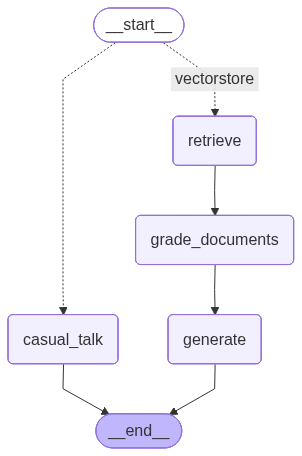

In [22]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    #  실패 시 통과
    pass


In [23]:
inputs = {
    "question": "서울시 자율주행 계획"
}

app.invoke(inputs) # workflow를 실행합니다.

------ROUTE------
---Routing to vectorstore---
------RETRIEVE------
------GRADE------
------GENERATE------


{'question': '서울시 자율주행 계획',
 'generation': AIMessage(content=[{'type': 'text', 'text': "서울시의 자율주행 계획은 **'2040 서울도시기본계획'**을 바탕으로 미래 교통수단에 선제적으로 대응하고, 도시의 이동 효율성을 극대화하는 것을 목표로 하고 있습니다. 주요 내용은 다음과 같습니다.\n\n### 1. 단계별 추진 목표 및 로드맵\n*   **2030년까지:** 간선도로급 이상의 도로에서 자율주행이 가능한 도로 인프라 환경을 우선적으로 조성합니다.\n*   **2040년까지:** 서울 전역에 자율주행 운행 환경을 구축하고, 자율주행 차량의 **수송 분담률 10% 달성**을 목표로 합니다.\n\n### 2. 인프라 및 기술 기반 구축\n*   **스마트 도로 인프라:** 도로 정밀지도, 교통 데이터 등을 갖춘 스마트 도로 인프라를 단계적·지속적으로 확대 구축합니다.\n*   **시범 운영 및 서비스 확대:** 자율주행차 시범 운영 지역을 확대하고, 지역 거점별 특성에 맞는 다양한 서비스를 구현합니다.\n*   **자율주행 버스:** 서울 전역을 연결하는 자율주행 버스 노선을 설계하여 대중교통 체계와 결합합니다.\n\n### 3. 미래 교통 네트워크 및 서비스 체계\n*   **기능별 역할 정립:** 자율주행 공유 수단 및 수요응답형 교통(DRT)은 중·단거리 지역과 거점 간을 연결하는 지선 체계의 핵심 역할을 담당하게 됩니다.\n*   **모빌리티 허브(Mobility Hub) 구축:** 서울 전역의 도심 및 광역 거점에 미래 교통과 기존 교통을 연결하는 '모빌리티 허브'를 도입합니다. 이곳에서는 교통뿐만 아니라 공공서비스, 물류, 상업 기능이 복합적으로 제공됩니다.\n*   **통합 모빌리티 플랫폼(MaaS):** 기존 교통수단과 자율주행차, UAM 등을 통합 관제하고 최적의 경로를 제공하는 대중교통 중심의 MaaS 체계를 구축합니다.\n\n### 4. 제도적 지원 및 환경 정비\n*   

In [24]:
inputs = {
    "question": "잘 지내고 있어?"
}

app.invoke(inputs) # workflow를 실행합니다.

------ROUTE------
---Routing to casual_talk---
------CASUAL TALK------


{'question': '잘 지내고 있어?',
 'generation': AIMessage(content=[{'type': 'text', 'text': '네, 덕분에 아주 잘 지내고 있어요! 물어봐 주셔서 감사합니다. 😊\n\n사용자님은 오늘 하루 어떻게 보내고 계신가요? 기분 좋은 일이나 특별한 일은 없으셨나요? 제가 도와드릴 일이 있다면 언제든 말씀해 주세요!', 'extras': {'signature': 'EogMCoUMAb4+9vthCroUn28ocKOtomWTiGIM6sx3UPTNG3/stabe8EIDtqCHQKSlCKquL0kgEfUhW9mkG0R/Onedl01+3pKwGxjYsbQSzQLRbzVoVlD4exL5y6ut4Tb75OCx7bGe1e1cjXAKFDYiqkKcup5AQHyBCLKAqzkoEoYzrmehOHBaMzULRYam6QfAFkXzmbstO2GnMr9aNqvf6pkEp6fxrMHniJPBVMUfiI4aUycjAIPBpUvXfvcYXMxzyD44qpJ1xwAzmwnkRoNc5Y/4vVX3LBkteUgRhwq18cUKR/6QCTfyoYXutF7qKsedHztFVhGCT8Yyk46Ts3OSPw/IoJhogY/wvTH3eey9jr8QgqfhwO7QL0joUQWbv6QpvqScdakqnva5ydX2nbUvHZgdPHjs7OipXbMdHIYwIIwInyF2kTC2REXnnskEqSu7k7x0sRk6p4BHSHiF9VfuHl8vxuAMjXpQtIKYIgCjLz0AVdZXkCs96rh9F4f8efcV79JC6lwPzzGcxFogbFyCj3EcfU3z6KyU/7vm3QdME6vdRocxQEUWO3cdMOaZirmLElGNXEjY1KEnqB0CBuS5Q5NtIR66s8aaWOtoIiy7DvbdVa0Tg2l0YCYTmtvYbD3HLjh0P0SmzIxM8gmhgyeKnXy9k5JYsfJOSCj6Wont8INBifAREvGtMu7/nWEGBxnWjHoM7roEyr5lbup4q/MAHc+nUmqNVat7o0QM8qvA7oNMtHKszjICy9qPm9hQgE0l

In [25]:
inputs = {
    "question": "서울시의 자율주행 차량 관련 계획은 무엇이 있나요?"
}

for msg, meta in app.stream(inputs, stream_mode='messages'):
    print(msg.content, end='')


------ROUTE------
[{'type': 'text', 'text': '{"datasource":"', 'index': 0}][{'type': 'text', 'text': 'vectorstore"}', 'index': 0}][{'type': 'text', 'text': '', 'extras': {'signature': 'EuMICuAIAb4+9vt4ANkTCcCE/uZL6nQDo50lTUGQXNp0ZrixWNTlen5zv9JTf2uUYtDtoThsbk9vXCBcwiTjH2Ndo9r69Y9VQ8d5912oS07TRQJuPKOTGXwuSH7mlPFY2i8FCk088vupeO3KpVa1A6cj/ZfuVYSgS223nwHdZTSpns/7g8UmZ0EO3TJ9oz2hMczp6zH4DAU6wDhCtKHVTVianzENfDzVjRBDmIvilIkwv+VlHrua/RNokUd2wmdvIXr840gVCpxpzww8MA19aoWqT0j9xpBnAUE60BAS49cWkBiU64KMLmZBkQ/Gr3jL6o+Eoe955a+llr54/xWAGas/qnAo4SFgCf4OlciBo660M8OQRuqvoJzIdvQuNm2shugItVgjCRe01YMXFpTkbtFKiBuPhxI61SzHKdiBL5vtEo2C96Ds7qauBnwnLJi/lob7jB0yvZOXo7A9hFKagc1AonpcYdSZhwWhw3p+J2wDL6HxRMrZi9QGf8FPNMY3SGw3c13nCBBWKTrLSx57oMV/ISrnDMf0+f0EK0/2aay/9MJYqtFUIgMaXvP3tqH+4elPj5NUu0DHYHbNBokmX4kpucNlEGRsv9bX927dn8Tx+wICfabJmcXqpZArcNIQ5QcDZBl2n6nSKyHAZ8ocCFy8H7Z7ikF9trfJSBW3ADGnH9D7jCVKxVI1O2RP6b+/a8mrg3GHm1UgfZ4Xxe2/xN+QgPqqXlrSXZVAPnqHSOgEpR/Ai/xJqXvE2LDk+ocFFZgajTIKvJDx8HR82zm88KTqvM9v1SN8F0wUTS/auGe8+96